# Parquet Files Analysis Report

This notebook provides a comprehensive analysis of all Parquet files in the workspace, including:
- Column information and missing values
- Row counts
- Potential relationships and references
- Interesting findings and anomalies

In [1]:
import polars as pl
from pathlib import Path

# Set display options for better readability
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_str_lengths(120)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Scan Parquet Files

In [2]:
# Discover all parquet files
parquet_files = []
base_path = Path(r"d:\\CS116\\ProjectNumberOne")
file_sizes_mb = {}

for file in sorted(base_path.rglob("*.parquet")):
    parquet_files.append(file)

print(f"Found {len(parquet_files)} parquet file(s):\n")

# Use Polars lazy scans for fast schema discovery, then collect once for downstream analysis
file_info_rows = []
data_frames = {}
for file in parquet_files:
    lazy_frame = pl.scan_parquet(file)
    schema = lazy_frame.collect_schema()
    df = lazy_frame.collect()
    file_name = file.name
    file_sizes_mb[file_name] = file.stat().st_size / (1024 * 1024)
    data_frames[file_name] = df
    file_info_rows.append({
        'File Path': str(file.relative_to(base_path)),
        'Size (MB)': f"{file_sizes_mb[file_name]:.2f}",
        'Columns': len(schema),
        'Rows': df.height
    })

file_info_df = pl.DataFrame(file_info_rows)
print(file_info_df)
print("\n" + "="*80 + "\n")

Found 3 parquet file(s):

shape: (3, 4)
┌───────────────────────────────┬───────────┬─────────┬──────────┐
│ File Path                     ┆ Size (MB) ┆ Columns ┆ Rows     │
│ ---                           ┆ ---       ┆ ---     ┆ ---      │
│ str                           ┆ str       ┆ i64     ┆ i64      │
╞═══════════════════════════════╪═══════════╪═════════╪══════════╡
│ event_full_2025.parquet       ┆ 363.41    ┆ 5       ┆ 37684823 │
│ items.parquet                 ┆ 2.77      ┆ 11      ┆ 29823    │
│ transaction_full_2025.parquet ┆ 632.38    ┆ 8       ┆ 37684823 │
└───────────────────────────────┴───────────┴─────────┴──────────┘




## 2. Column Analysis Report

Detailed analysis of columns, data types, meanings, and missing values for each file.

In [3]:
for file_name, df in data_frames.items():
    print(f"\n{'='*80}")
    print(f"FILE: {file_name}")
    print(f"{'='*80}")
    print(f"Shape: {df.height} rows × {df.width} columns\n")
    
    # Create column analysis
    column_analysis = []
    for col in df.columns:
        series = df.get_column(col)
        null_count = series.null_count()
        null_percentage = (null_count / df.height) * 100 if df.height else 0
        dtype = str(series.dtype)
        
        # Infer meaning from column name
        meaning = col.replace('_', ' ').title()
        
        column_analysis.append({
            'Column': col,
            'Type': dtype,
            'NaN Count': null_count,
            'NaN %': f"{null_percentage:.2f}%",
            'Unique Values': series.n_unique(),
            'Meaning': meaning
        })
    
    analysis_df = pl.DataFrame(column_analysis)
    print(analysis_df)
    print()


FILE: event_full_2025.parquet
Shape: 37684823 rows × 5 columns

shape: (5, 6)
┌──────────────┬──────────────────────────┬───────────┬───────┬───────────────┬──────────────┐
│ Column       ┆ Type                     ┆ NaN Count ┆ NaN % ┆ Unique Values ┆ Meaning      │
│ ---          ┆ ---                      ┆ ---       ┆ ---   ┆ ---           ┆ ---          │
│ str          ┆ str                      ┆ i64       ┆ str   ┆ i64           ┆ str          │
╞══════════════╪══════════════════════════╪═══════════╪═══════╪═══════════════╪══════════════╡
│ customer_id  ┆ Int32                    ┆ 0         ┆ 0.00% ┆ 2821898       ┆ Customer Id  │
│ item_id      ┆ String                   ┆ 0         ┆ 0.00% ┆ 19891         ┆ Item Id      │
│ quantity     ┆ Int32                    ┆ 0         ┆ 0.00% ┆ 126           ┆ Quantity     │
│ event_type   ┆ String                   ┆ 0         ┆ 0.00% ┆ 1             ┆ Event Type   │
│ updated_date ┆ Datetime(time_unit='us', ┆ 0         ┆ 0.00% ┆ 17

## 3. Row Count Analysis

In [4]:
# Row count analysis
print("ROW COUNT SUMMARY")
print("="*80)
row_count_data = []
for file_name, df in data_frames.items():
    row_count_data.append({
        'File': file_name,
        'Row Count': f"{df.height:,}",
        'Column Count': df.width
    })

row_count_df = pl.DataFrame(row_count_data)
print(row_count_df)
print("\nTotal rows across all files:", sum(df.height for df in data_frames.values()))
print("="*80 + "\n")

ROW COUNT SUMMARY
shape: (3, 3)
┌───────────────────────────────┬────────────┬──────────────┐
│ File                          ┆ Row Count  ┆ Column Count │
│ ---                           ┆ ---        ┆ ---          │
│ str                           ┆ str        ┆ i64          │
╞═══════════════════════════════╪════════════╪══════════════╡
│ event_full_2025.parquet       ┆ 37,684,823 ┆ 5            │
│ items.parquet                 ┆ 29,823     ┆ 11           │
│ transaction_full_2025.parquet ┆ 37,684,823 ┆ 8            │
└───────────────────────────────┴────────────┴──────────────┘

Total rows across all files: 75399469



## 4. Column Relationships and References

Detect potential foreign key relationships between columns across files.

In [5]:
print("COLUMN RELATIONSHIPS AND REFERENCES")
print("="*80)

# Extract all columns from all files
all_columns_by_file = {}
for file_name, df in data_frames.items():
    all_columns_by_file[file_name] = set(df.columns)

# Look for common column names that might indicate relationships
print("\n1. Columns with matching names across files (potential foreign keys):\n")
relationships_found = False

for file1_name, cols1 in all_columns_by_file.items():
    for file2_name, cols2 in all_columns_by_file.items():
        if file1_name < file2_name:  # Avoid duplicates
            common_cols = cols1 & cols2
            if common_cols:
                relationships_found = True
                print(f"   {file1_name} <---> {file2_name}")
                for col in sorted(common_cols):
                    print(f"      • {col}")

# Look for potential ID columns that might reference other tables
print("\n2. Identified ID/Reference columns:\n")
id_cols = {}
for file_name, df in data_frames.items():
    file_id_cols = [col for col in df.columns if 'id' in col.lower() or 'key' in col.lower()]
    if file_id_cols:
        id_cols[file_name] = file_id_cols
        print(f"   {file_name}:")
        for col in file_id_cols:
            unique_count = df.get_column(col).n_unique()
            print(f"      • {col}: {unique_count} unique values")

print("\n3. Value Overlap Analysis:\n")
# Check for value overlaps between ID columns
for file1_name, file1_df in data_frames.items():
    id_cols_1 = [col for col in file1_df.columns if 'id' in col.lower()]
    for col1 in id_cols_1:
        for file2_name, file2_df in data_frames.items():
            if file1_name != file2_name:
                id_cols_2 = [col for col in file2_df.columns if 'id' in col.lower()]
                for col2 in id_cols_2:
                    # Check for value overlap
                    left_values = set(file1_df.get_column(col1).drop_nulls().to_list())
                    right_values = set(file2_df.get_column(col2).drop_nulls().to_list())
                    overlap = left_values & right_values
                    denominator = max(file1_df.get_column(col1).n_unique(), file2_df.get_column(col2).n_unique())
                    overlap_percentage = (len(overlap) / denominator) * 100 if denominator > 0 else 0
                    
                    if overlap_percentage > 50:  # Significant overlap
                        print(f"   {file1_name}.{col1} <-> {file2_name}.{col2}")
                        print(f"      Overlap: {len(overlap)} values ({overlap_percentage:.1f}%)")

if not relationships_found and not id_cols:
    print("   No obvious relationships detected through naming conventions.")

print("\n" + "="*80 + "\n")

COLUMN RELATIONSHIPS AND REFERENCES

1. Columns with matching names across files (potential foreign keys):

   event_full_2025.parquet <---> items.parquet
      • item_id
   event_full_2025.parquet <---> transaction_full_2025.parquet
      • customer_id
      • event_type
      • item_id
      • quantity
      • updated_date
   items.parquet <---> transaction_full_2025.parquet
      • item_id
      • price

2. Identified ID/Reference columns:

   event_full_2025.parquet:
      • customer_id: 2821898 unique values
      • item_id: 19891 unique values
   items.parquet:
      • item_id: 29823 unique values
   transaction_full_2025.parquet:
      • bill_id: 17548336 unique values
      • customer_id: 2821898 unique values
      • item_id: 19891 unique values

3. Value Overlap Analysis:

   event_full_2025.parquet.customer_id <-> transaction_full_2025.parquet.customer_id
      Overlap: 2821898 values (100.0%)
   event_full_2025.parquet.item_id <-> items.parquet.item_id
      Overlap: 19853 

## 5. Interesting Findings and Anomalies

In [6]:
print("INTERESTING FINDINGS AND ANOMALIES")
print("="*80)

findings = []

# 1. High NaN percentage columns
print("\n1. HIGH MISSING VALUE COLUMNS (> 30% NaN):\n")
high_nan_found = False
for file_name, df in data_frames.items():
    for col in df.columns:
        series = df.get_column(col)
        nan_percentage = (series.null_count() / len(df)) * 100 if len(df) else 0
        if nan_percentage > 30:
            high_nan_found = True
            print(f"   {file_name}.{col}: {nan_percentage:.2f}% missing ({series.null_count()} values)")
            findings.append(f"High missing values in {file_name}.{col}")

if not high_nan_found:
    print("   No columns with >30% missing values found.")

# 2. Duplicate rows analysis
print("\n2. DUPLICATE ROWS ANALYSIS:\n")
for file_name, df in data_frames.items():
    total_duplicates = int(df.is_duplicated().sum())
    if total_duplicates > 0:
        dup_percentage = (total_duplicates / len(df)) * 100 if len(df) else 0
        print(f"   {file_name}: {total_duplicates} duplicate rows ({dup_percentage:.2f}%)")
        findings.append(f"Duplicates found in {file_name}: {total_duplicates} rows")
    else:
        print(f"   {file_name}: No complete duplicate rows")

# 3. Data type anomalies
print("\n3. DATA TYPE ANOMALIES:\n")
for file_name, df in data_frames.items():
    print(f"   {file_name}:")
    for col in df.columns:
        dtype = df.schema[col]
        # Check for objects that might be dates, numbers, etc.
        if dtype == pl.Utf8:
            sample_values = df.get_column(col).drop_nulls().head(3).to_list()
            print(f"      • {col} (string): {sample_values}")

# 4. Column statistics for numeric columns
print("\n4. NUMERIC COLUMNS STATISTICS:\n")
for file_name, df in data_frames.items():
    numeric_cols = [name for name, dtype in df.schema.items() if dtype in pl.NUMERIC_DTYPES]
    if len(numeric_cols) > 0:
        print(f"   {file_name}:")
        for col in numeric_cols:
            series = df.get_column(col)
            min_value = series.min()
            max_value = series.max()
            mean_value = series.mean()
            std_value = series.std()
            print(f"      • {col}")
            print(f"         Range: [{min_value:.2f}, {max_value:.2f}]")
            print(f"         Mean: {mean_value:.2f}, Std: {std_value:.2f}")

# 5. Unique value patterns
print("\n5. UNIQUE VALUE PATTERNS:\n")
for file_name, df in data_frames.items():
    print(f"   {file_name}:")
    for col in df.columns:
        series = df.get_column(col)
        unique_count = series.n_unique()
        total_count = len(df)
        uniqueness_ratio = unique_count / total_count if total_count else 0
        
        # Flag columns with very high or very low uniqueness
        if uniqueness_ratio > 0.95:
            print(f"      • {col}: {unique_count} unique values (HIGHLY UNIQUE - {uniqueness_ratio*100:.1f}%)")
            findings.append(f"Highly unique column: {file_name}.{col}")
        elif uniqueness_ratio < 0.01:
            print(f"      • {col}: {unique_count} unique values (LOW VARIETY - {uniqueness_ratio*100:.2f}%)")
            findings.append(f"Low variety column: {file_name}.{col}")

# 6. Size comparison
print("\n6. FILE SIZE AND DENSITY COMPARISON:\n")
size_data = []
for file_name, df in data_frames.items():
    total_cells = df.height * df.width
    size_data.append({
        'File': file_name,
        'Rows': df.height,
        'Cols': df.width,
        'Total Cells': total_cells,
        'File Size (MB)': f"{file_sizes_mb[file_name]:.2f}",
        'Cells / MB': f"{(total_cells / file_sizes_mb[file_name]):.2f}" if file_sizes_mb[file_name] else 'N/A'
    })

size_df = pl.DataFrame(size_data)
print(size_df)

print("\n" + "="*80)
print("\nSUMMARY OF KEY FINDINGS:")
print("="*80)
if findings:
    for i, finding in enumerate(findings, 1):
        print(f"{i}. {finding}")
else:
    print("No major anomalies detected. Data appears clean and well-structured.")
print("\n")

INTERESTING FINDINGS AND ANOMALIES

1. HIGH MISSING VALUE COLUMNS (> 30% NaN):

   No columns with >30% missing values found.

2. DUPLICATE ROWS ANALYSIS:

   event_full_2025.parquet: 3745 duplicate rows (0.01%)
   items.parquet: No complete duplicate rows
   transaction_full_2025.parquet: 360 duplicate rows (0.00%)

3. DATA TYPE ANOMALIES:

   event_full_2025.parquet:
      • item_id (string): ['6767000000002', '2265000000027', '6497000000004']
      • event_type (string): ['Purchase', 'Purchase', 'Purchase']
   items.parquet:
      • item_id (string): ['0008040000046', '0502020000004', '0007010000886']
      • category_l1 (string): ['Đồ chơi & Sách', 'Babycare', 'Babycare']
      • category_l2 (string): ['1Y+', 'Bình sữa, phụ kiện', 'Bình sữa, phụ kiện']
      • category_l3 (string): ['Học tập và phát triển tư duy', 'Núm ty', 'Núm ty']
      • category (string): ['Siêu nhân, robot', 'Núm ty Dr Brown', 'Núm ty Pigeon']
      • brand (string): ['WinWinToys', "Dr.Brown's", 'Pigeon']
   

C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_31904\1926143121.py:46: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  numeric_cols = [name for name, dtype in df.schema.items() if dtype in pl.NUMERIC_DTYPES]


   event_full_2025.parquet:
      • customer_id
         Range: [15126.00, 9540467.00]
         Mean: 5724827.81, Std: 2609682.28
      • quantity
         Range: [1.00, 1400.00]
         Mean: 1.59, Std: 2.52
   items.parquet:
      • price
         Range: [0.00, 20990000.00]
         Mean: 192117.19, Std: 499585.01
      • sale_status
         Range: [0.00, 1.00]
         Mean: 0.23, Std: 0.42
   transaction_full_2025.parquet:
      • bill_id
         Range: [109123952.00, 158512318.00]
         Mean: 143794772.93, Std: 8346169.21
      • customer_id
         Range: [15126.00, 9540467.00]
         Mean: 5724827.81, Std: 2609682.28
      • price
         Range: [0.00, 20990000.00]
         Mean: 166157.57, Std: 196087.71
      • quantity
         Range: [1.00, 1400.00]
         Mean: 1.59, Std: 2.52

5. UNIQUE VALUE PATTERNS:

   event_full_2025.parquet:
      • item_id: 19891 unique values (LOW VARIETY - 0.05%)
      • quantity: 126 unique values (LOW VARIETY - 0.00%)
      • event_t

In [9]:
# List category/brand/manufacturer breakdowns for items.parquet
items_df = data_frames.get("items.parquet")
if items_df is None:
    raise RuntimeError("items.parquet not found in data_frames")

candidate_cols = [
    "category", "category_l1", "category_l2", "category_l3",
    "brand", "manufacturer", "sale_status", "size"
]

available_cols = [c for c in candidate_cols if c in items_df.columns]
if not available_cols:
    print("No target category/brand columns found in items.parquet")
else:
    for col in available_cols:
        print("\n" + "="*80)
        print(f"Column: {col} (value -> number of rows / distinct item_id count)")
        print("-"*80)
        tmp = items_df.with_columns(pl.col(col).fill_null("<NULL>").alias(col))
        breakdown = (
            tmp.group_by(col, maintain_order=False)
               .agg(
                   rows=pl.len(),
                   distinct_item_ids=pl.col("item_id").n_unique()
               )
               .sort("rows", descending=True)
        )
        print(breakdown)


Column: category (value -> number of rows / distinct item_id count)
--------------------------------------------------------------------------------
shape: (1_684, 3)
┌────────────────────────────────────┬──────┬───────────────────┐
│ category                           ┆ rows ┆ distinct_item_ids │
│ ---                                ┆ ---  ┆ ---               │
│ str                                ┆ u32  ┆ u32               │
╞════════════════════════════════════╪══════╪═══════════════════╡
│ Bộ bé trai Animo                   ┆ 1108 ┆ 1108              │
│ Bộ bé trai Animo Easy              ┆ 1084 ┆ 1084              │
│ Bộ quần áo bé gái                  ┆ 744  ┆ 744               │
│ Bộ Modal lẻ                        ┆ 740  ┆ 740               │
│ Áo sơ sinh                         ┆ 714  ┆ 714               │
│ Bodysuit                           ┆ 641  ┆ 641               │
│ Bộ bé gái Animo Easy               ┆ 640  ┆ 640               │
│ Quần sơ sinh                       ┆ 6

Transaction file: transaction_full_2025.parquet
Date column: updated_date
Quantity column: quantity

Monthly sale quantity (12 months)
shape: (12, 2)
┌─────────┬───────────────┐
│ month   ┆ sale_quantity │
│ ---     ┆ ---           │
│ str     ┆ i32           │
╞═════════╪═══════════════╡
│ 2025-01 ┆ 5111048       │
│ 2025-02 ┆ 4496932       │
│ 2025-03 ┆ 4822234       │
│ 2025-04 ┆ 4902122       │
│ 2025-05 ┆ 5451526       │
│ 2025-06 ┆ 5366211       │
│ 2025-07 ┆ 5268305       │
│ 2025-08 ┆ 5875812       │
│ 2025-09 ┆ 5665199       │
│ 2025-10 ┆ 6050888       │
│ 2025-11 ┆ 6639636       │
│ 2025-12 ┆ 178556        │
└─────────┴───────────────┘

Daily sale quantity (365 days)
shape: (365, 2)
┌────────────┬───────────────┐
│ day        ┆ sale_quantity │
│ ---        ┆ ---           │
│ date       ┆ i32           │
╞════════════╪═══════════════╡
│ 2024-12-02 ┆ 0             │
│ 2024-12-03 ┆ 0             │
│ 2024-12-04 ┆ 0             │
│ 2024-12-05 ┆ 0             │
│ 2024-12-06 ┆ 0   

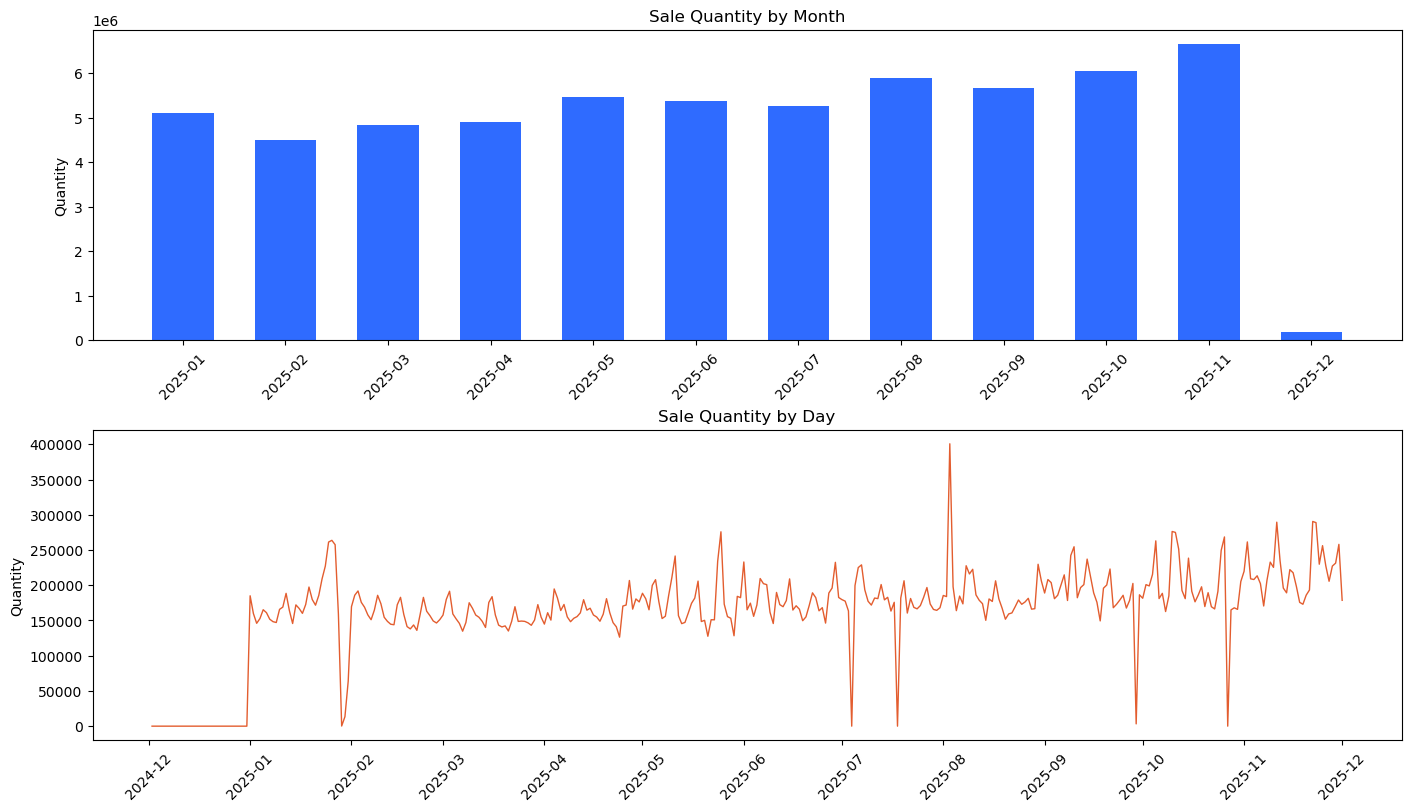

In [15]:
from datetime import date, timedelta
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

txn_df = data_frames["transaction_full_2025.parquet"]

sales = (
    txn_df.select(
        pl.col("updated_date").cast(pl.Datetime, strict=False).alias("date"),
        pl.col("quantity").fill_null(0).alias("quantity"),
    )
    .drop_nulls("date")
    .with_columns(pl.col("date").dt.date().alias("day"))
)

max_day = sales.select(pl.col("day").max()).item()
month_end = date(max_day.year, max_day.month, 1)
month_start = date((month_end.year * 12 + month_end.month - 12) // 12, ((month_end.year * 12 + month_end.month - 12) % 12) + 1, 1)
day_start = max_day - timedelta(days=364)

monthly_raw = (
    sales.with_columns(pl.col("date").dt.strftime("%Y-%m").alias("month"))
    .group_by("month")
    .agg(pl.col("quantity").sum().alias("sale_quantity"))
    .sort("month")
)

daily_raw = (
    sales.filter(pl.col("day") >= pl.lit(day_start))
    .group_by("day")
    .agg(pl.col("quantity").sum().alias("sale_quantity"))
    .sort("day")
)

monthly_index = pl.DataFrame({
    "month": [d.strftime("%Y-%m") for d in pl.date_range(month_start, month_end, interval="1mo", eager=True).to_list()]
})

monthly = (
    monthly_index.join(monthly_raw, on="month", how="left")
    .with_columns(pl.col("sale_quantity").fill_null(0))
    .sort("month")
)

daily = (
    pl.DataFrame({"day": pl.date_range(day_start, max_day, interval="1d", eager=True)})
    .join(daily_raw, on="day", how="left")
    .with_columns(pl.col("sale_quantity").fill_null(0))
    .sort("day")
)

print("Transaction file: transaction_full_2025.parquet")
print("Date column: updated_date")
print("Quantity column: quantity")

print("\nMonthly sale quantity (12 months)")
print(monthly)

print("\nDaily sale quantity (365 days)")
print(daily)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

axes[0].bar(monthly["month"].to_list(), monthly["sale_quantity"].to_list(), color="#2F6BFF", width=0.6)
axes[0].set_title("Sale Quantity by Month")
axes[0].set_ylabel("Quantity")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(daily["day"].to_list(), daily["sale_quantity"].to_list(), color="#E35D2F", linewidth=1)
axes[1].set_title("Sale Quantity by Day")
axes[1].set_ylabel("Quantity")
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].tick_params(axis="x", rotation=45)

plt.show()